In [2]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from medicaid_spending.config import PARQUET_PATH

In [3]:
conn = duckdb.connect()
df = conn.execute("""
    SELECT
        HCPCS_CODE,
        BILLING_PROVIDER_NPI_NUM,
        SUM(TOTAL_PAID) / SUM(TOTAL_CLAIMS) AS paid_per_claim,
        SUM(TOTAL_CLAIMS) AS total_claims
    FROM read_parquet(?)
    GROUP BY HCPCS_CODE, BILLING_PROVIDER_NPI_NUM
    HAVING SUM(TOTAL_CLAIMS) > 100
""", [str(PARQUET_PATH)]).df()

  HCPCS_CODE BILLING_PROVIDER_NPI_NUM  PROVIDER_AVG_COST  PERCENT_ABOVE_AVG
0      1160F               1891775128         138.830000      108648.293598
1      1159F               1891775128         138.830000       86707.689607
2      A9270               1164758868        5083.741656       81311.110815
3      1126F               1225685332         199.444444       79856.517591
4      2001F               1891775128         136.646937       75228.635456
5      1160F               1386191989          95.643772       74819.664270
6      1126F               1831548197         184.466019       73851.724089
7      1160F               1801343405          93.586245       73207.962648
8      G2211               1679262737        3261.642657       71507.744844
9      2000F               1891775128         135.556750       62992.394500


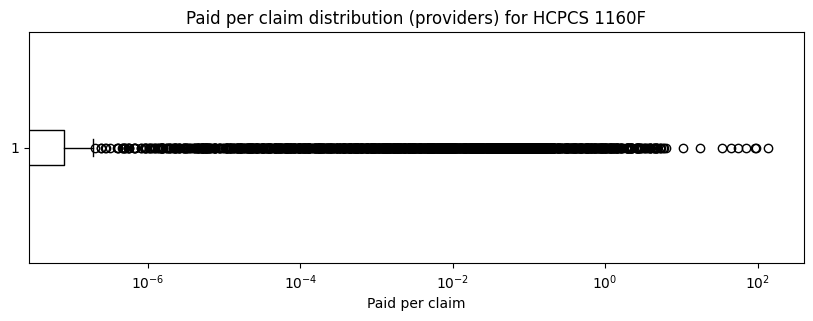

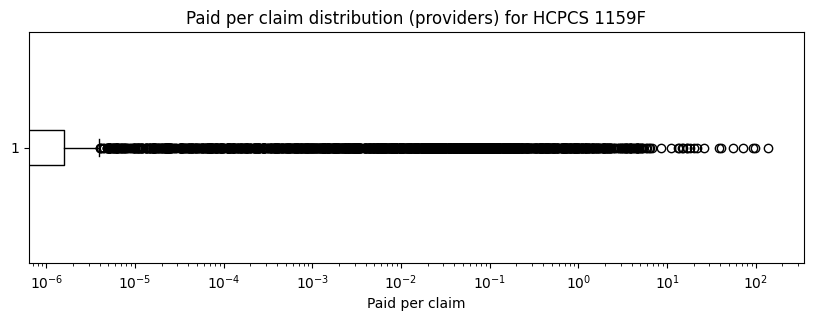

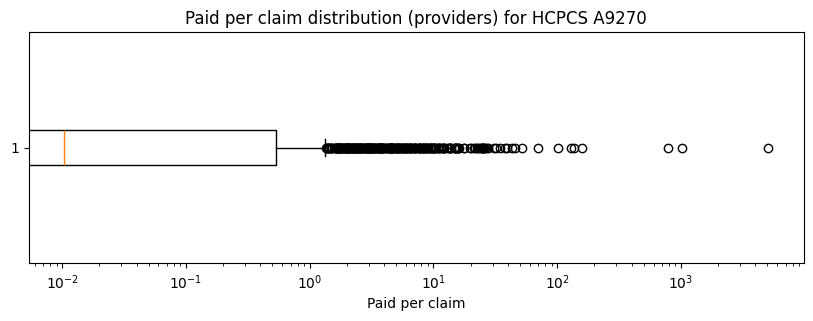

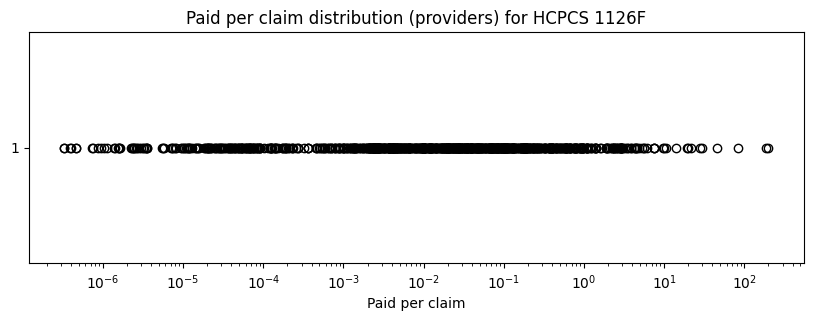

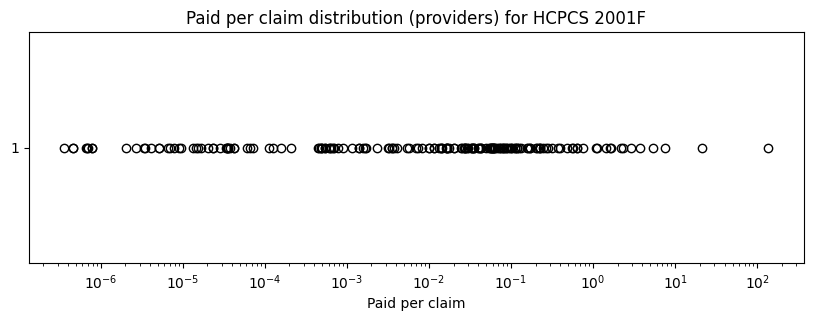

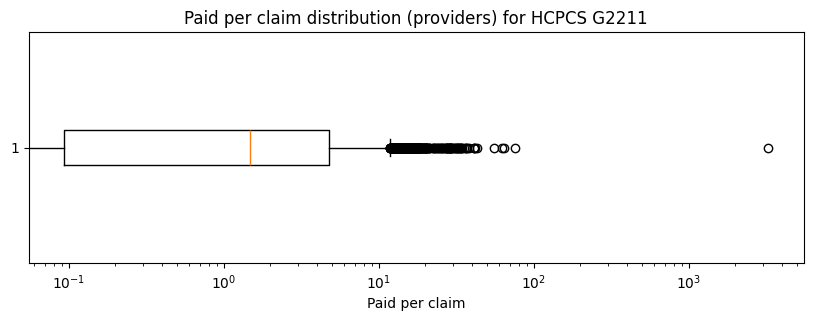

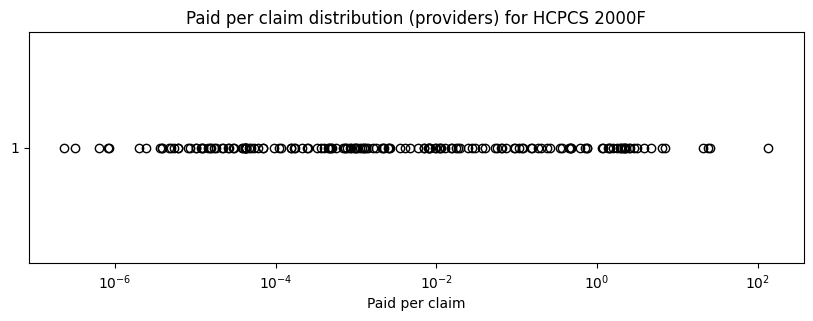

In [ ]:
# ----------------------------
# 1) Find outliers per HCPCS
# ----------------------------
outliers_list = []
summary_list = []

for hcpcs, group in df.groupby("HCPCS_CODE"):
    q1 = group["paid_per_claim"].quantile(0.25)
    q3 = group["paid_per_claim"].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr

    outliers = group[group["paid_per_claim"] > upper_bound]

    avg_cost = group["paid_per_claim"].mean()

    for _, row in outliers.iterrows():
        outliers_list.append({
            "HCPCS_CODE": hcpcs,
            "BILLING_PROVIDER_NPI_NUM": row["BILLING_PROVIDER_NPI_NUM"],
            "PROVIDER_AVG_COST": row["paid_per_claim"],
            "PERCENT_ABOVE_AVG": ((row["paid_per_claim"] - avg_cost) / avg_cost) * 100
        })

    summary_list.append({
        "HCPCS_CODE": hcpcs,
        "AVG_PAID_PER_CLAIM": avg_cost,
        "Q1": q1,
        "Q3": q3,
        "UPPER_BOUND": upper_bound,
        "N_PROVIDERS": len(group),
        "N_OUTLIERS": len(outliers)
    })

outliers_df = pd.DataFrame(outliers_list)
summary_table = pd.DataFrame(summary_list)

final_table = (
    outliers_df
    .sort_values("PERCENT_ABOVE_AVG", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print(final_table)
top_hcpcs = final_table["HCPCS_CODE"].unique()

for hcpcs in top_hcpcs:
    group = df[df["HCPCS_CODE"] == hcpcs]

    plt.figure(figsize=(10, 3))
    plt.boxplot(group["paid_per_claim"], vert=False)
    plt.xscale("log")
    plt.title(f"Paid per claim distribution (providers) for HCPCS {hcpcs}")
    plt.xlabel("Paid per claim")

    plt.show()